# The Boundary of the No-LLM Position

**Intent, priority and resolution for eight support threads — the judgment notebook 09 said was worth
escalating — as three typed questions per thread, and then as properties on the graph.**

Notebook 09 drew a line. GLiNER2.5, asked to classify support-ticket intent, landed near chance; asked
for priority, it landed *at* chance — a near-constant predictor emitting `high` for seven of eight threads
at 0.75–1.00 confidence. The README's explanation is the useful part: *intent is written down; severity is
not, so a span model has nothing to key on.* Of every task in that notebook, this was the one it named as
worth sending to a model that can read.

So send it. The state is the thread — a JSON object with the subject, the channel, and the turns as an
array, which is the form the TypeSafe docs recommend for a conversation. Three questions ride on it: a
`Choice` over the six intents, a `Score` over the four priorities (they are ordered, which is what a
`Score` is for), and a `Noul` for whether the thread ended resolved. Eight threads, eight requests.

Eight is a small number. What this notebook can show is whether the judgments are right on the eight,
what their confidence looks like when they are and are not, and how they land in the graph — not a
benchmark. The gold is `kgx.data.customer_service.GOLD_INTENTS`; the baseline is notebook 09's GLiNER
classification, reproduced here.

Needs `TYPESAFE_API_KEY`, or the cached responses in `output/typesafe_cache/`.

## 0. Setup

In [1]:
import os, sys, time, json, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import msgspec
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 210)
pd.set_option("display.max_colwidth", 52)

import kgx
import kgx.typesafe as kts
from typesafe_sdk import Choice, Noul, Score
from kgx.data.customer_service import THREADS, GOLD_INTENTS, INTENT_LABELS, PRIORITY_LABELS

ts = kts.CachedTypeSafe(cache_dir=ROOT / "output" / "typesafe_cache")
print(ts)
if not ts.available:
    print("TYPESAFE_API_KEY is not set -- replaying from cache; anything new will raise.")

def show(obj):
    print(json.dumps(json.loads(msgspec.json.encode(obj)), indent=2, ensure_ascii=False))

print(f"\n{len(THREADS)} threads, {sum(len(t['turns']) for t in THREADS)} turns")
display(pd.DataFrame([{"thread": t["thread_id"], "channel": t["channel"], "turns": len(t["turns"]),
                       "subject": t["subject"], **GOLD_INTENTS[t["thread_id"]]} for t in THREADS])
        .set_index("thread"))

CachedTypeSafe(model='jev-latest', cache_dir='../output/typesafe_cache', key=unset)
TYPESAFE_API_KEY is not set -- replaying from cache; anything new will raise.

8 threads, 95 turns


,channel,turns,subject,intent,priority,resolved
thread,,,,,,
t01,email,12,Aurora 14 shutting down at 40% battery,technical support,high,True
t02,chat,13,left Halcyon Bud keeps dropping out,technical support,medium,True
t03,phone log,12,"N600 ordered on the tenth, still not shipped",order status,low,True
t04,email,11,Charged twice for Priority Care on 28 March,billing dispute,medium,True
t05,chat,14,"replacement N600 is dead, want the money back",refund request,high,True
t06,email,10,Fourth request: refund RF-2261 has still not bee...,complaint,urgent,False
t07,chat,11,cancel Priority Care and order F-88132,cancellation,medium,True
t08,chat,12,charging case only charges the right earbud,technical support,low,False


---

## 1. The baseline: notebook 09's classifier, reproduced

`GLiNER2.5`'s `classify_text` over the rendered thread, with the same label sets. This is the cell the
README's finding came from.

In [2]:
extractor = kgx.GlinerExtractor()

rows = []
for t in THREADS:
    text = "\n".join(f"{x['speaker']}: {x['text']}" for x in t["turns"])
    out = extractor.model.classify_text(
        text, {"intent": list(INTENT_LABELS), "priority": list(PRIORITY_LABELS)}, include_confidence=True)
    gold = GOLD_INTENTS[t["thread_id"]]
    rows.append({"thread": t["thread_id"],
                 "intent": out["intent"]["label"], "intent ok": out["intent"]["label"] == gold["intent"],
                 "intent conf": round(out["intent"]["confidence"], 2),
                 "priority": out["priority"]["label"], "priority ok": out["priority"]["label"] == gold["priority"],
                 "priority conf": round(out["priority"]["confidence"], 2)})
G = pd.DataFrame(rows).set_index("thread")
display(G)
print(f"GLiNER  intent {G['intent ok'].mean():.0%} ({G['intent ok'].sum()}/8)   "
      f"priority {G['priority ok'].mean():.0%} ({G['priority ok'].sum()}/8)   "
      f"chance: intent {1/len(INTENT_LABELS):.0%}, priority {1/len(PRIORITY_LABELS):.0%}")

,intent,intent ok,intent conf,priority,priority ok,priority conf
thread,,,,,,
t01,refund request,False,0.92,high,True,1.00
t02,technical support,True,0.87,high,False,0.95
t03,cancellation,False,0.96,high,False,0.91
t04,refund request,False,0.75,high,False,0.77
t05,refund request,True,0.99,high,True,0.99
t06,refund request,False,0.87,high,False,0.99
t07,cancellation,True,1.00,low,False,0.98
t08,complaint,False,0.80,high,False,0.99


GLiNER  intent 38% (3/8)   priority 25% (2/8)   chance: intent 17%, priority 25%


---

## 2. Three questions on a thread

The `Score` levels are the point of care. A `Score` needs each level to describe a concrete situation that
stands on its own — *not* the bare word `high`, which the docs warn against — so the four priorities are
written as the operational situations a support desk would recognise. The intent criteria are the six
labels with one clause each.

In [3]:
INTENTS = {
    "refund request":    "The customer wants money returned for something they paid for.",
    "technical support": "Something the customer owns is not working and they want it fixed or diagnosed.",
    "order status":      "The customer wants to know where an order is or when it will arrive.",
    "billing dispute":   "The customer disagrees with a charge, an amount, or an invoice.",
    "complaint":         "The customer is expressing dissatisfaction and wants it acknowledged, beyond any single fix.",
    "cancellation":      "The customer wants to cancel an order, a plan, or a service.",
}
PRIORITY = [
    "Low: no deadline, nothing is broken, the customer is content to wait.",
    "Medium: a real problem with a workaround, or a question that should be answered within normal service levels.",
    "High: the customer is blocked or out of pocket, is asking repeatedly, or a service level is at risk.",
    "Urgent: an unresolved failure with an explicit deadline, a threat to leave or escalate publicly, or a breached commitment.",
]
assert len(PRIORITY) == len(PRIORITY_LABELS)

def thread_state(t):
    return {"subject": t["subject"], "channel": t["channel"], "opened": t["opened"],
            "turns": [{"speaker": x["speaker"], "text": x["text"]} for x in t["turns"]]}

def thread_questions():
    return {
        "intent": Choice(instructions="What does the customer want from this thread, taken as a whole? "
                                      "Judge the customer's turns in `turns`, not the agent's.",
                         criteria=INTENTS),
        "priority": Score(instructions="How urgently does this thread need attention, as of its last turn?",
                          criteria=PRIORITY),
        "resolved": Noul(instructions="By the last turn in `turns`, has the customer's issue been resolved "
                                      "to the customer's evident satisfaction?",
                         criteria={"true": "The customer's problem is fixed or their request granted, and they accept it.",
                                   "false": "The issue is open, deferred, escalated, or the customer is still dissatisfied."}),
    }

print("the request for one thread (turns elided):\n")
st = thread_state(THREADS[0]); st["turns"] = f"<{len(st['turns'])} turns>"
show({"state": st, "questions": thread_questions()})

the request for one thread (turns elided):

{
  "state": {
    "subject": "Aurora 14 shutting down at 40% battery",
    "channel": "email",
    "opened": "2026-03-02",
    "turns": "<12 turns>"
  },
  "questions": {
    "intent": {
      "type": "choice",
      "criteria": {
        "refund request": "The customer wants money returned for something they paid for.",
        "technical support": "Something the customer owns is not working and they want it fixed or diagnosed.",
        "order status": "The customer wants to know where an order is or when it will arrive.",
        "billing dispute": "The customer disagrees with a charge, an amount, or an invoice.",
        "complaint": "The customer is expressing dissatisfaction and wants it acknowledged, beyond any single fix.",
        "cancellation": "The customer wants to cancel an order, a plan, or a service."
      },
      "instructions": "What does the customer want from this thread, taken as a whole? Judge the customer's turns in 

In [4]:
rows = []
for t in THREADS:
    r = ts.ask(thread_state(t), thread_questions())
    gold = GOLD_INTENTS[t["thread_id"]]
    intent, prio, res = r.choices["intent"], r.scores["priority"], r.nouls["resolved"]
    level = min(int(prio.score + 0.5), len(PRIORITY_LABELS) - 1)
    rows.append({"thread": t["thread_id"],
                 "intent": intent.choice, "intent ok": intent.choice == gold["intent"],
                 "intent conf": round(intent.confidence, 2),
                 "priority": PRIORITY_LABELS[level], "priority ok": PRIORITY_LABELS[level] == gold["priority"],
                 "priority score": round(prio.score, 2), "priority conf": round(prio.confidence, 2),
                 "resolved": res.noul >= 0.5, "resolved ok": (res.noul >= 0.5) == gold["resolved"],
                 "p resolved": round(res.noul, 2),
                 "gold": f"{gold['intent']} / {gold['priority']} / {'resolved' if gold['resolved'] else 'open'}"})
T = pd.DataFrame(rows).set_index("thread")
display(T)
for col in ("intent", "priority", "resolved"):
    print(f"System One  {col:<9} {T[col + ' ok'].mean():.0%} ({T[col + ' ok'].sum()}/8)")

,intent,intent ok,intent conf,priority,priority ok,priority score,priority conf,resolved,resolved ok,p resolved,gold
thread,,,,,,,,,,,
t01,refund request,False,0.94,high,True,2.42,0.42,True,True,0.78,technical support / high / resolved
t02,technical support,True,1.00,low,False,0.07,0.93,True,True,0.97,technical support / medium / resolved
t03,complaint,False,0.70,high,False,1.85,0.03,True,True,0.64,order status / low / resolved
t04,billing dispute,True,0.53,medium,True,0.50,0.50,True,True,0.92,billing dispute / medium / resolved
t05,refund request,True,1.00,medium,False,0.65,0.35,True,True,0.86,refund request / high / resolved
t06,refund request,False,1.00,urgent,True,2.99,0.99,False,True,0.08,complaint / urgent / open
t07,cancellation,True,1.00,low,False,0.00,1.00,True,True,0.97,cancellation / medium / resolved
t08,technical support,True,0.70,urgent,False,2.71,0.71,False,True,0.05,technical support / low / open


System One  intent    62% (5/8)
System One  priority  38% (3/8)
System One  resolved  100% (8/8)


**Resolved: 8 of 8. Intent: 5 of 8 against GLiNER's 3. Priority: 3 of 8, which on eight items is not
distinguishable from chance.** Take them in that order, because they are three different findings.

`resolved` is the clean one, and the README predicted it: *intent is written down; severity is not.*
Whether a thread ended resolved is written down — the customer says *"Do it"* or *"Please do not close
it"* — and the `Noul` puts the two open threads at 0.05 and 0.08 and the six resolved ones at 0.64 to
0.97, with nothing in between.

The three intent disagreements are disagreements about *which* intent. t01 opens as a shutdown fault and
closes with the customer accepting a refund for a depot failure; t06's subject line is *"Fourth request:
refund RF-2261 has still not been paid"*, which the gold calls a `complaint` and the model calls a
`refund request` at 1.00; t03 is an order-status query that ends *"It is the second time this year,
though."* The question said *taken as a whole*, the gold labels the opening ask, and the model did what it
was told. That is a defect in my question, and a real one: a support desk routes on the opening ask.

Priority is where the model and the gold do not share a definition. t08's customer says *"Small one"* and
the gold says `low`; the model says `urgent` at 2.71, keying on *"third thing this year"* and an open
issue. t07 and t02 are `low` at confidence 1.00 and 0.93 against a gold of `medium`. The `Score` levels
were written by me, operationally — *blocked or out of pocket, asking repeatedly* — and the gold's
priorities were assigned by whoever wrote the corpus, on a scale the notebook never saw. Three of eight is
what agreement between two unshared definitions looks like.

### 2.1 Reading the confidences

Right answers and wrong ones should look different, or the number is not doing its job. Plot every
thread's three confidences, and mark the ones the gold disagrees with.

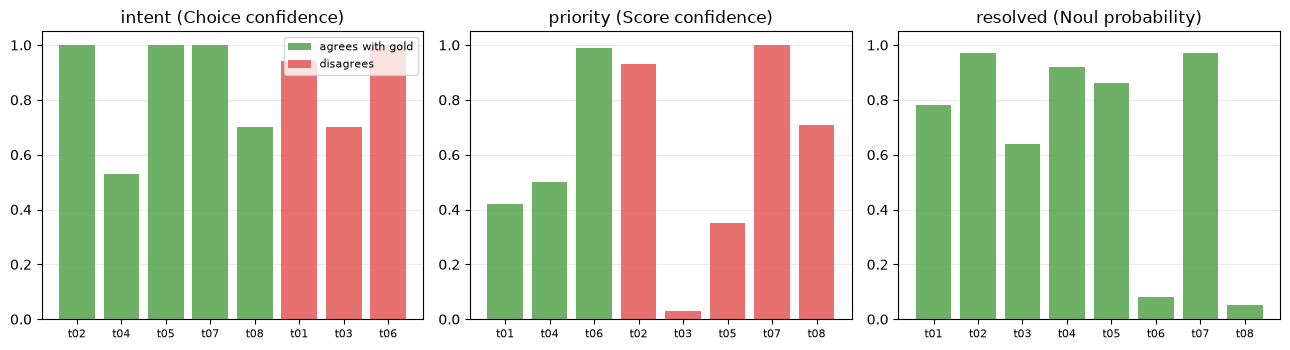

priority as an expected level, against the rounded label and the gold:


,priority score,priority,priority conf,gold
thread,,,,
t01,2.42,high,0.42,technical support / high / resolved
t02,0.07,low,0.93,technical support / medium / resolved
t03,1.85,high,0.03,order status / low / resolved
t04,0.50,medium,0.50,billing dispute / medium / resolved
t05,0.65,medium,0.35,refund request / high / resolved
t06,2.99,urgent,0.99,complaint / urgent / open
t07,0.00,low,1.00,cancellation / medium / resolved
t08,2.71,urgent,0.71,technical support / low / open


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (col, conf, label) in zip(axes, [("intent ok", "intent conf", "intent (Choice confidence)"),
                                          ("priority ok", "priority conf", "priority (Score confidence)"),
                                          ("resolved ok", "p resolved", "resolved (Noul probability)")]):
    for ok, colour in [(True, "#54A24B"), (False, "#E45756")]:
        sub = T[T[col] == ok]
        ax.bar(sub.index, sub[conf], color=colour, alpha=0.85, label="agrees with gold" if ok else "disagrees")
    ax.set_ylim(0, 1.05); ax.set_title(label); ax.grid(alpha=0.25, axis="y"); ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelsize=8)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("priority as an expected level, against the rounded label and the gold:")
display(T[["priority score", "priority", "priority conf", "gold"]])

**The errors are confident, and that is the finding.** The two `resolved` misses do not exist; the
`resolved` bar chart is all green. The intent misses come at 0.94, 1.00 and 0.70 — the first two are not
hedges, they are the model answering a differently worded question with conviction. The priority column
has both kinds: t03 at confidence 0.03 (*I do not know*; the expected level 1.85 sits between `medium` and
`high` with the mass split), and t07, t02, t08 at 1.00, 0.93 and 0.71 — confidently placed on a scale the
gold does not use.

Notebook 10 §2.2 made the same point about a `Noul`: ambiguity in the *question* does not come back as an
uncertain answer. Here it is again for a `Choice` and a `Score`. Confidence measures how sure the model is
of its answer to the question as asked; it cannot measure whether the question was the right one.

---

## 3. Route on confidence

The [confidence-routing pattern](https://docs.typesafe.ai/patterns/confidence-routing.md) in one rule:
act on what the model is sure of, queue the rest for a person. With eight threads the interesting question
is not the accuracy at each cutoff but *which* threads a cutoff sends to review, and whether those are the
ones a person would have wanted to see.

In [6]:
def route(row, min_conf=0.6):
    weakest = min(row["intent conf"], row["priority conf"], abs(row["p resolved"] - 0.5) * 2)
    return "auto" if weakest >= min_conf else "review"

for cut in (0.5, 0.7, 0.9):
    T[f"route @ {cut}"] = T.apply(route, axis=1, min_conf=cut)
display(T[["intent", "intent conf", "priority", "priority conf", "p resolved",
           "route @ 0.5", "route @ 0.7", "route @ 0.9"]])

for cut in (0.5, 0.7, 0.9):
    auto = T[T[f"route @ {cut}"] == "auto"]
    wrong_auto = int(((~auto["intent ok"]) | (~auto["priority ok"]) | (~auto["resolved ok"])).sum())
    print(f"cutoff {cut}: {len(auto)} auto, {8 - len(auto)} to review; "
          f"auto-handled threads with any error: {wrong_auto}")

,intent,intent conf,priority,priority conf,p resolved,route @ 0.5,route @ 0.7,route @ 0.9
thread,,,,,,,,
t01,refund request,0.94,high,0.42,0.78,review,review,review
t02,technical support,1.00,low,0.93,0.97,auto,auto,auto
t03,complaint,0.70,high,0.03,0.64,review,review,review
t04,billing dispute,0.53,medium,0.50,0.92,auto,review,review
t05,refund request,1.00,medium,0.35,0.86,review,review,review
t06,refund request,1.00,urgent,0.99,0.08,auto,auto,review
t07,cancellation,1.00,low,1.00,0.97,auto,auto,auto
t08,technical support,0.70,urgent,0.71,0.05,auto,auto,review


cutoff 0.5: 5 auto, 3 to review; auto-handled threads with any error: 4
cutoff 0.7: 4 auto, 4 to review; auto-handled threads with any error: 4
cutoff 0.9: 2 auto, 6 to review; auto-handled threads with any error: 2


**Confidence routing caught none of the disagreements, because none of them were low-confidence.** At a
cutoff of 0.7 four threads go through automatically and all four carry a disagreement with the gold; at
0.9 two go through and both do. The threads sent to review are the ones with a hedged priority (t03 at
0.03, t04 at 0.50, t05 at 0.35) — genuinely uncertain calls a person should see — and those are not where
the gold disagreed.

Read correctly, that is not a failure of the pattern. Routing on confidence routes *model uncertainty*,
and it did: the three least certain priority calls went to a person. What it cannot route is
*definitional disagreement* — a `Score` whose levels mean something different from the labeller's, an
intent question that reads the thread's end where the gold reads its start. Those have to be fixed in the
question, and the fix is cheap: rewrite the levels to the desk's own definition of priority, ask for the
opening intent, and re-run eight requests. The only thing this notebook cannot do about it is pretend the
eight-thread gold is large enough to tune against.

---

## 4. Into the graph

Notebook 09 built the customer-service graph from these threads — issues, orders, products, agents. What
it could not put on the thread was a judgment about the thread. These are typed values, so they go on as
properties, with their confidence beside them, and a `Thread` node ties them to the customer.

In [7]:
CUSTOMERS = {"t01": "Priya Raman", "t02": "Marcus Webb", "t03": "Ana Duarte",
             "t04": "Priya Raman", "t05": "Marcus Webb", "t06": "Ana Duarte",
             "t07": "Priya Raman", "t08": "Marcus Webb"}

lines = ["// Generated by notebook 14 -- thread-level judgments as properties",
         "CREATE CONSTRAINT thread_id IF NOT EXISTS FOR (t:Thread) REQUIRE t.thread_id IS UNIQUE;", ""]
for t in THREADS:
    r = T.loc[t["thread_id"]]
    props = {"subject": t["subject"], "channel": t["channel"], "opened": t["opened"],
             "intent": r["intent"], "intent_confidence": float(r["intent conf"]),
             "priority": r["priority"], "priority_score": float(r["priority score"]),
             "priority_confidence": float(r["priority conf"]),
             "resolved": bool(r["resolved"]), "p_resolved": float(r["p resolved"]),
             "route": r["route @ 0.7"]}
    body = ", ".join(f"t.{k} = {json.dumps(v)}" for k, v in props.items())
    lines.append(f"MERGE (t:Thread {{thread_id: {json.dumps(t['thread_id'])}}}) SET {body};")
    lines.append(f"MERGE (c:Customer {{name: {json.dumps(CUSTOMERS[t['thread_id']])}}})")
    lines.append(f"WITH c MATCH (t:Thread {{thread_id: {json.dumps(t['thread_id'])}}}) MERGE (c)-[:OPENED]->(t);")
cypher = "\n".join(lines)
(ROOT / "output" / "typesafe_threads.cypher").write_text(cypher)
print("\n".join(lines[:8]))
print(f"\n-> output/typesafe_threads.cypher ({len(lines)} lines)")

// Generated by notebook 14 -- thread-level judgments as properties
CREATE CONSTRAINT thread_id IF NOT EXISTS FOR (t:Thread) REQUIRE t.thread_id IS UNIQUE;

MERGE (t:Thread {thread_id: "t01"}) SET t.subject = "Aurora 14 shutting down at 40% battery", t.channel = "email", t.opened = "2026-03-02", t.intent = "refund request", t.intent_confidence = 0.94, t.priority = "high", t.priority_score = 2.42, t.priority_confidence = 0.42, t.resolved = true, t.p_resolved = 0.78, t.route = "review";
MERGE (c:Customer {name: "Priya Raman"})
WITH c MATCH (t:Thread {thread_id: "t01"}) MERGE (c)-[:OPENED]->(t);
MERGE (t:Thread {thread_id: "t02"}) SET t.subject = "left Halcyon Bud keeps dropping out", t.channel = "chat", t.opened = "2026-03-11", t.intent = "technical support", t.intent_confidence = 1.0, t.priority = "low", t.priority_score = 0.07, t.priority_confidence = 0.93, t.resolved = true, t.p_resolved = 0.97, t.route = "auto";
MERGE (c:Customer {name: "Marcus Webb"})

-> output/typesafe_threads.cyp

And the query that motivated all of it — the one a span model could not have answered:

```cypher
// open threads that need a person, most urgent first
MATCH (c:Customer)-[:OPENED]->(t:Thread)
WHERE t.resolved = false AND (t.priority IN ['high', 'urgent'] OR t.route = 'review')
RETURN c.name, t.thread_id, t.intent, t.priority, t.priority_score, t.route
ORDER BY t.priority_score DESC
```

---

## 5. What it cost

In [8]:
stats = ts.stats()
display(pd.Series(stats).to_frame("value"))
print(f"\n8 threads, 8 requests, 3 questions each -- "
      f"{stats['input_tokens_observed'] / 8:.0f} input tokens per thread")

,value
requests_live,0.0
requests_cached,8.0
questions,24.0
questions_per_request,3.0
input_tokens_billed,0.0
output_tokens_billed,0.0
input_tokens_observed,10968.0
output_tokens_observed,786.0
ms_spent,0.0
ms_per_request_observed,229.0



8 threads, 8 requests, 3 questions each -- 1371 input tokens per thread


---

## 6. Findings

*Eight threads. Measured, not asserted, and not a benchmark.*

In [9]:
print("=" * 78)
print("SUMMARY".center(78))
print("=" * 78)
print(f"  {'':12} {'GLiNER2.5':>12} {'System One':>12}")
print(f"  {'intent':12} {G['intent ok'].sum():>9}/8   {T['intent ok'].sum():>9}/8")
print(f"  {'priority':12} {G['priority ok'].sum():>9}/8   {T['priority ok'].sum():>9}/8")
print(f"  {'resolved':12} {'--':>12} {T['resolved ok'].sum():>9}/8")
for cut in (0.5, 0.7, 0.9):
    auto = T[T[f"route @ {cut}"] == "auto"]
    wrong = int(((~auto["intent ok"]) | (~auto["priority ok"]) | (~auto["resolved ok"])).sum())
    print(f"  route @ {cut}: {len(auto)} auto ({wrong} with an error), {8 - len(auto)} to review")
print("=" * 78)

                                   SUMMARY                                    
                  GLiNER2.5   System One
  intent               3/8           5/8
  priority             2/8           3/8
  resolved               --         8/8
  route @ 0.5: 5 auto (4 with an error), 3 to review
  route @ 0.7: 4 auto (4 with an error), 4 to review
  route @ 0.9: 2 auto (2 with an error), 6 to review


### The thing that is written down, the model reads — 8 of 8

The README's account of notebook 09 was that GLiNER could not classify priority because severity is not
in the text, and could barely classify intent. A System One `Noul` on *is this resolved* — a thing that
is in the text, in the customer's last turn — scores 8 of 8 with a clean gap between open (0.05–0.08) and
resolved (0.64–0.97). Intent, partly written down, goes from 3 of 8 to 5 of 8.

### Priority is a definition, and the model was given mine

3 of 8, against a chance rate of 2 of 8, with the misses confident. The `Score` levels were written for
this notebook as operational situations; the gold was assigned on a scale the notebook never saw. A
`Score` cannot agree with a rubric it was not shown, and the disagreements — t08 `urgent` against a
customer who says *"Small one"* — are legible as exactly that. On a real desk the levels would be the
desk's own, and there would be more than eight threads to check them on.

### The intent "errors" are the question's fault

*Taken as a whole* was my phrase, and the model took the thread as a whole: t01 ends with a refund, t06's
subject line asks for one, t03 ends with a grievance. The gold labels the opening ask. The desk routes on
the opening ask. A question worded to the desk's definition would probably have scored better, and the
honest thing to record is that an instruction changed three labels at confidence 0.94–1.00.

### Confidence routes model uncertainty, not definitional disagreement

The three hedged priority calls went to review, correctly. The confident disagreements went through,
because confidence has nothing to say about whether the question matched the labeller's. Notebook 10 §2.2
found this for a `Noul`; here it holds for a `Choice` and a `Score`. Fix the question, not the threshold.

### Eight threads

Everything above is eight items. The 8/8 is real, the 5/8 and 3/8 are suggestive, and the point of the
notebook is the *shape* of the errors — which is visible at eight — rather than any rate, which is not.
The Cypher in §4 is the deliverable: a thread node carrying intent, priority, resolution and their
confidences, so that the query *open threads that need a person* has something to run against.